# Acoustic Scan 

In [1]:
# matching pursuit
# depth profiling
# attenuation with high f. reflection ok, transmission no
# look at acoustic resonances, dip in attenuation
# 

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
import sys


sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/M3Learning-Util/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/AutoPhysLearn/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonic_ml/src')


from scipy.signal import butter, sosfiltfilt
import copy
import math
import time
from tqdm import tqdm
import pickleJar as pj
import tomography as tm

In [3]:
from viz.visualize_scan_data import *
from IPython.display import display
import plotly.graph_objects as go

## Dataloader with preprocessing

In [4]:
from data import datasets
from data.datasets import morlet_1D_dataset_real

dset = morlet_1D_dataset_real(sq3lite_path='/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.sqlite3',
                              # dset_name='voltage_transmission_forward',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                            #   crops = [(0,4000)] #(15000,19000)
                            ) 

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle already exists. Conversion aborted.
preprocessing data...


  0%|          | 0/1911 [00:00<?, ?it/s]/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting/pickleJar.py:1185: RuntimeWarning: divide by zero encountered in log10
  logData = np.log10(abs(data))
100%|██████████| 1911/1911 [00:01<00:00, 1331.02it/s]


In [5]:
# echo = dset.data["processed_voltage_echo_forward"]#[1034]       
# fft_morlet = np.fft.fftshift(np.fft.fft(echo, axes=-1), axes=-1)/max(dset.freq)*2
# mag = np.abs(fft_morlet)
# # plt.plot(freq[len(mag)//2:len(mag)//2+200],mag[len(mag)//2:len(mag)//2+200])
# plt.plot(freq[len(mag[1034])//2:len(mag[1034])//2+200],mag[1034][len(mag[1034])//2:len(mag[1034])//2+200])

In [6]:
def func(x, **kwargs): # normalize by length of signal
    return np.fft.fftshift(np.fft.fft(x, axis=-1), axes=-1)
    
dset.preprocess_data_additional(func, 'fft', axis=0)

In [7]:
# for k in dset.data.keys(): 
#     if not isinstance(k, int): print(k)

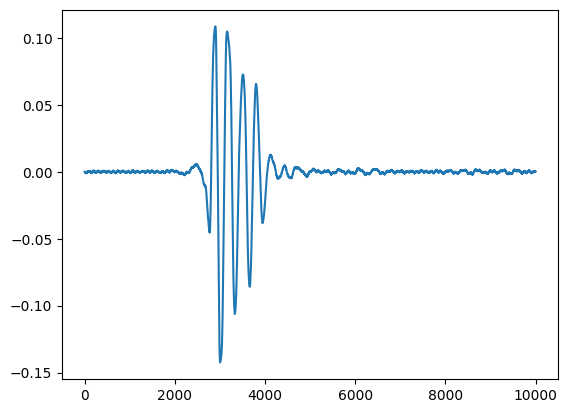

In [8]:
dat = dset.data['processed_voltage_echo_forward'][1050]
plt.plot(dat)

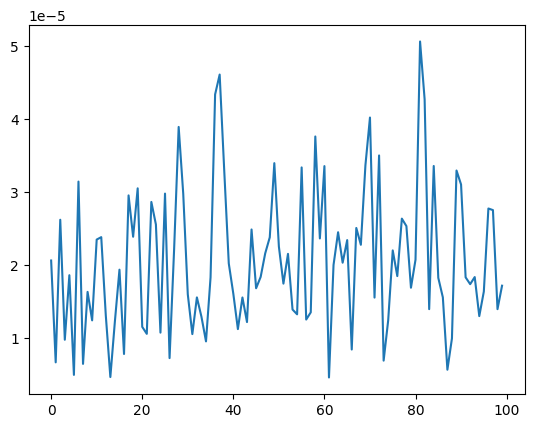

In [9]:
dat = dset[1050][1]
mag = np.abs(dat)[len(dat)//2:len(dat)//2+200]
plt.plot(mag)

## FFT visualization and scipy fitter

### plain fft

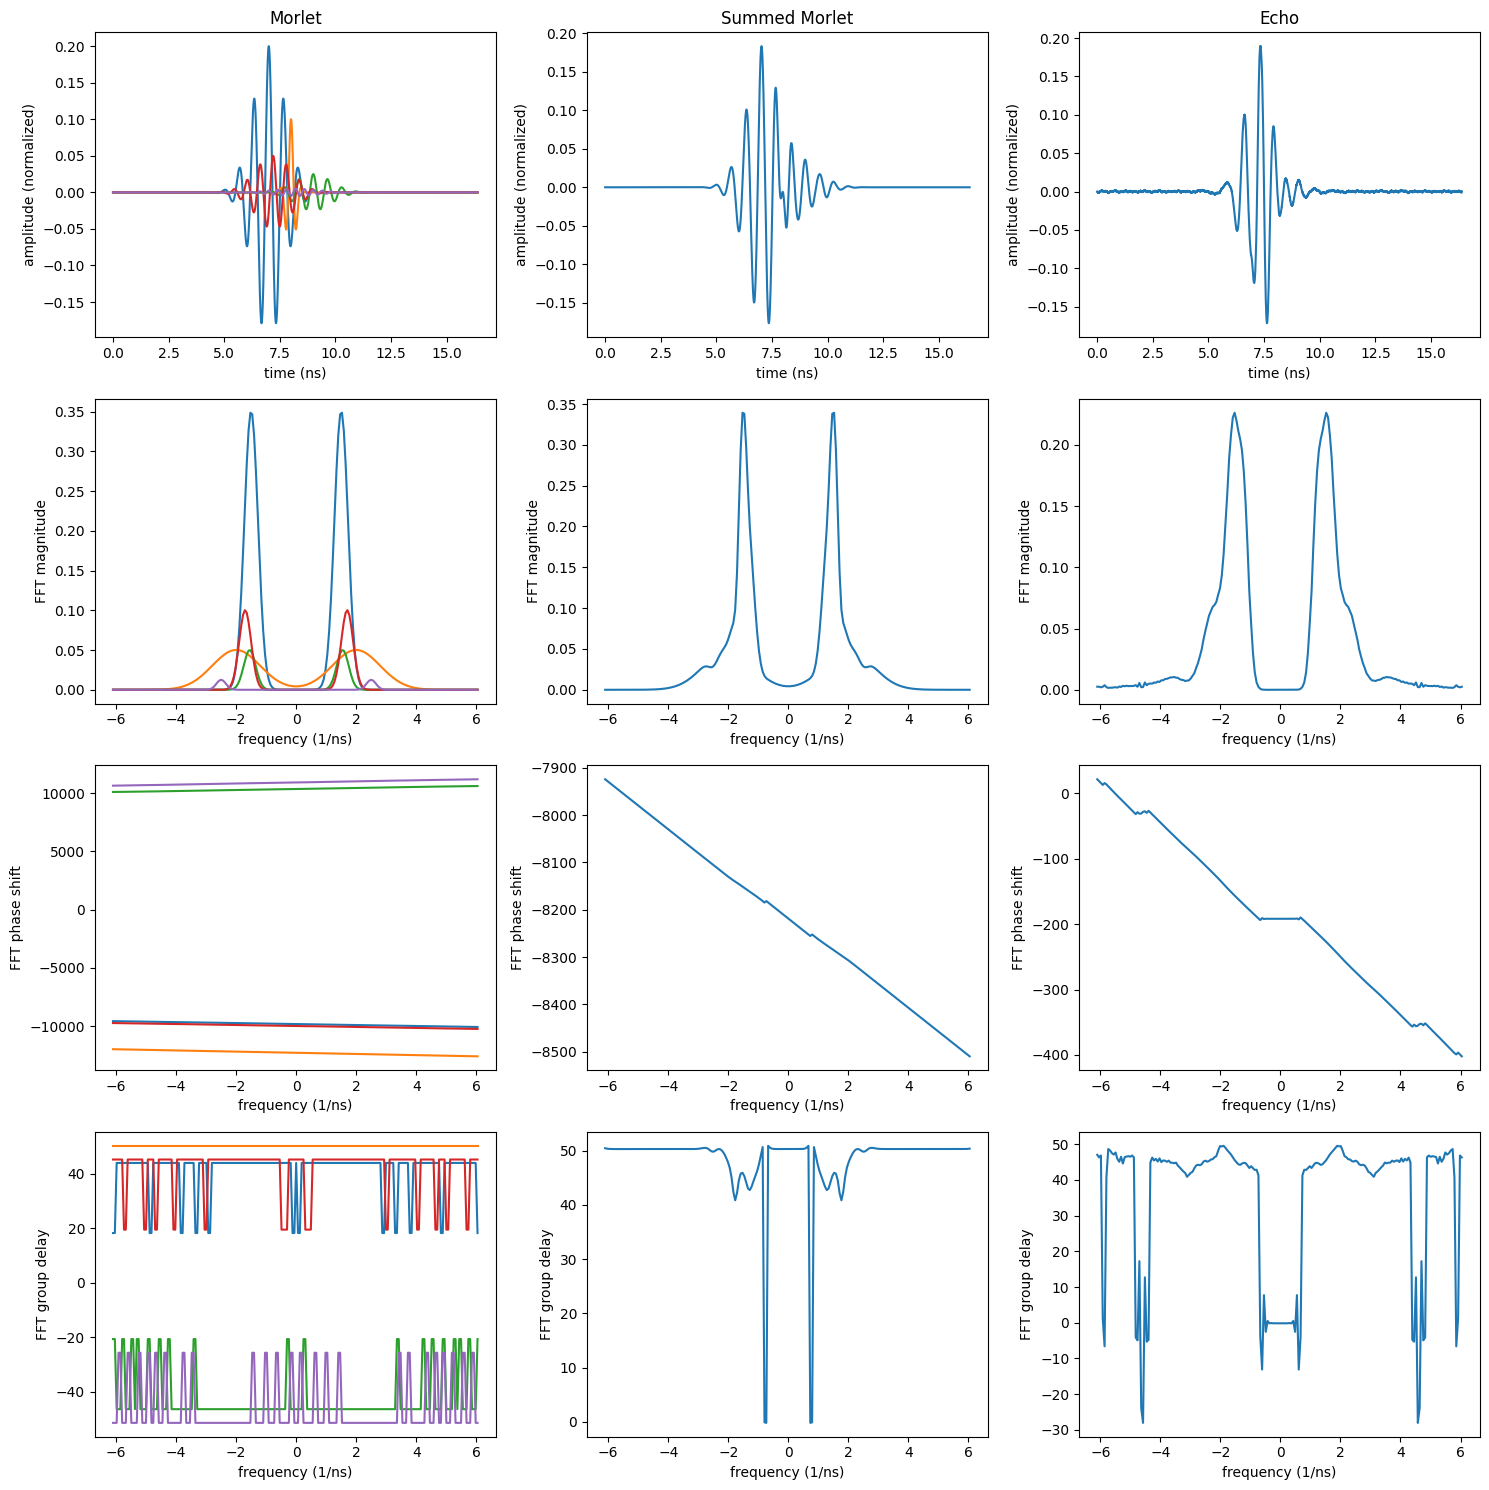

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from models.morlet_fitter import morlet_1D_fitters_real
import torch

idx = 1034
data_crop = 2**13
freq_crop = [data_crop//2-100,data_crop//2+100]
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
parameters = torch.tensor([[ [0.2, 3500, 350, 3.0e-03],
                            [0.1, 4000, 100, 4e-03],
                            [0.025, 4500, 400, 3.1e-03],
                            [0.05, 3600, 400, 3.4e-03],
                            [0.005, 4100, 500, 5e-03] ]] )
fitter = morlet_1D_fitters_real(limits=[1, dset.spec_len, dset.spec_len / 5, 0.05])
t = np.arange(0, data_crop*dset.dt, dset.dt)
freq = np.fft.fftshift(np.fft.fftfreq(data_crop, dset.dt))

axs[0, 0].set_title("Morlet")
test_morlet = fitter.generate_fit(parameters, data_crop)
for i,morlet in enumerate(test_morlet[0]):
    fft_morlet = np.fft.fftshift(np.fft.fft(morlet))/max(freq)
    axs[0, 0].plot(t, morlet)
    axs[1, 0].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_morlet[freq_crop[0]:freq_crop[1]]))
    morlet_phase = np.unwrap(np.angle(fft_morlet))
    axs[2, 0].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[freq_crop[0]:freq_crop[1]])
    axs[3, 0].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(morlet_phase, freq)[freq_crop[0]:freq_crop[1]])

axs[0, 1].set_title("Summed Morlet")
summed_morlet = test_morlet[0].sum(axis=0)    
axs[0, 1].plot(t, summed_morlet)
fft_summed_morlet = np.fft.fftshift(np.fft.fft(summed_morlet))/max(freq)
axs[1, 1].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_summed_morlet[freq_crop[0]:freq_crop[1]]))
morlet_phase = np.unwrap(np.angle(fft_summed_morlet))
axs[2, 1].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[freq_crop[0]:freq_crop[1]])
axs[3, 1].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(morlet_phase, freq)[freq_crop[0]:freq_crop[1]])


axs[0, 2].set_title("Echo")
echo = dset.data["processed_voltage_echo_forward"][idx][:data_crop]       
axs[0, 2].plot(t, echo)
fft_echo = np.fft.fftshift(np.fft.fft(echo))/max(freq)
axs[1, 2].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_echo[freq_crop[0]:freq_crop[1]]))
echo_phase = np.unwrap(np.angle(fft_echo))
axs[2, 2].plot(freq[freq_crop[0]:freq_crop[1]], echo_phase[freq_crop[0]:freq_crop[1]])
axs[3, 2].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(echo_phase, freq)[freq_crop[0]:freq_crop[1]])


for j in range(3):
    axs[0, j].set_xlabel("time (ns)")
    axs[0, j].set_ylabel("amplitude (normalized)")
    for i, y_label in enumerate(['FFT magnitude', 'FFT phase shift', 'FFT group delay']):
        axs[i+1, j].set_xlabel("frequency (1/ns)")
        axs[i+1, j].set_ylabel(y_label)
        
fig.tight_layout()

### fit echo with scipy

In [ ]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(fft_echo[len(freq)//2:len(freq)//2+100])
angles = np.unwrap(np.angle(fft_echo[len(freq)//2:len(freq)//2+100]))

def gaussian_5(x, 
               a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag.max(),mag.max(),mag.max(),mag.max(),mag.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
t = np.arange(0, data_crop*dset.dt, dset.dt)
morlet = np.array([morlet_function(t, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+100], 
             gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t, dset.data['processed_voltage_echo_forward'][1034][:data_crop], label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t, echo, label='echo')
axs[1,1].plot(t, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[0,i].set_xlabel('frequency (1/ns)')
    axs[1,i].set_xlabel('time (ns)')
    axs[1,i].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit toy

In [ ]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(fft_summed_morlet[len(freq)//2:len(freq)//2+100])
angles = np.unwrap(np.angle(fft_summed_morlet[len(freq)//2:len(freq)//2+100]))

def gaussian_5(x, 
               a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag.max(),mag.max(),mag.max(),mag.max(),mag.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## find group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
t = np.arange(0, data_crop*dset.dt, dset.dt)
morlet = np.array([morlet_function(t, parameters['a_t'][i], parameters['mu_t'][i], parameters['sigma_t'][i], parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
fig.suptitle('scipy curve_fit to fft toy dataset')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+100], 
             gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')


axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t, summed_morlet, label='toy morlet')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t, echo, label='echo')
axs[1,1].plot(t, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[0,i].set_xlabel('frequency (1/ns)')
    axs[1,i].set_xlabel('time (ns)')
    axs[1,i].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit echo with interpolation

In [ ]:
freq

In [ ]:
freq_

In [ ]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
t_ = np.arange(0, data_crop * dset.dt, dset.dt / 2)
t_[-1] = t[-1]
freq_ = np.fft.fftshift(np.fft.fftfreq(n=len(freq)*2, d=dset.dt/2))
f = freq_[len(freq_)//2:len(freq_)//2+200]

echo_ = interp1d(t, echo)(t_)
fft_echo_ = np.fft.fftshift(np.fft.fft(echo_))/max(freq_)
mag_ = np.abs(fft_echo_[len(freq_)//2:len(freq_)//2+200])
angles = np.unwrap(np.angle(fft_echo_[len(freq_)//2:len(freq_)//2+200]))

def gaussian_5(x, a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag_,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag_.max(),mag_.max(),mag_.max(),mag_.max(),mag_.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
morlet = np.array([morlet_function(t_, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(f, 
             gaussian(f, *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag_, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t_, echo_, label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t_, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t_, echo_, label='echo')
axs[1,1].plot(t_, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[0,i].set_xlabel('frequency (1/ns)')
    axs[1,i].set_xlabel('time (ns)')
    axs[1,i].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### fit toy with interpolation

In [ ]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# finding the phase shifts
t_ = np.arange(0, data_crop * dset.dt, dset.dt / 2)
t_[-1] = t[-1]
freq_ = np.fft.fftshift(np.fft.fftfreq(len(freq)*2, dset.dt/2))
f = freq_[len(freq_)//2:len(freq_)//2+200]
summed_morlet_ = interp1d(t, summed_morlet)(t_)
fft_summed_morlet_ = np.fft.fftshift(np.fft.fft(summed_morlet_))/max(freq_)
mag_ = np.abs(fft_summed_morlet_[len(freq_)//2:len(freq_)//2+200])
angles = np.unwrap(np.angle(fft_summed_morlet_[len(freq_)//2:len(freq_)//2+200]))

def gaussian_5(x, a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - mu5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1): return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 

def morlet_function(t, a, mu, sigma, f): return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(1j * 2 * np.pi * f * (t-mu))

## fit parameters
# try interpolating next?
popt, _ = curve_fit( gaussian_5, f, mag_,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag_.max(),mag_.max(),mag_.max(),mag_.max(),mag_.max(),
                             f[-1],f[-1],f[-1],f[-1],f[-1],
                             100,100,100,100,100]),
                    ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)

parameters = pd.DataFrame({'a_f':popt[:5], 'mu_f':popt[5:10], 'sigma_f':popt[10:] })

## fing group delays
means_f = popt[5:10]
group_delay = -np.gradient(angles, f)
interp = interp1d(f, group_delay)
g_delays = interp(means_f)

## calculate in time domain
parameters['mu_t'] = g_delays/2/np.pi
parameters['sigma_t'] = 1/2/np.pi/parameters['sigma_f']
parameters['a_t'] = parameters['a_f']/(2*np.pi*parameters['sigma_t']**2)**0.5
parameters = parameters.loc[:, ['a_f', 'mu_f', 'sigma_f', 'a_t', 'mu_t', 'sigma_t']]

## make morlet with given parameters
morlet = np.array([morlet_function(t_, 
                                   parameters['a_t'][i], 
                                   parameters['mu_t'][i], 
                                   parameters['sigma_t'][i], 
                                   parameters['mu_f'][i]) for i in range(len(parameters))])

parameters

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))

fig.suptitle('scipy curve_fit on fft of echo')

axs[0,0].set_title('scipy curve_fit to fft magnitude')
for i in range(5):
    axs[0,0].plot(freq[len(freq)//2:len(freq)//2+200], 
             gaussian(freq[len(freq)//2:len(freq)//2+200], *popt[[i, i+5, i+10]]), 
             label=f'gaussian {i}')
axs[0,0].plot(f, mag_, '--', label='data')
axs[0,0].plot(f, gaussian_5(f, *popt), '.', label='fit')
axs[0,0].legend()
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(means_f, g_delays, 'o', label='delays')
axs[0,1].legend()
axs[0,1].set_ylabel('phase (rad), group delay (ns)')

axs[1,0].set_title('morlet fit')
axs[1,0].plot(t_, summed_morlet_, label='echo')
for i in range(len(parameters['a_t'])): 
    axs[1,0].plot(t_, morlet[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('summed morlet')
axs[1,1].plot(t_, summed_morlet_, label='echo')
axs[1,1].plot(t_, morlet.sum(axis=0), label='morlet sum')
axs[1,1].legend()

for i in range(2):
    axs[0,i].set_xlabel('frequency (1/ns)')
    axs[1,i].set_xlabel('time (ns)')
    axs[1,i].set_ylabel('amplitude (normalized)')

fig.tight_layout()

## torch spectogram

In [ ]:
import torchaudio
import matplotlib.pyplot as plt
import torch
import numpy as np
from models.morlet_fitter import morlet_1D_fitters_real

i = 1034
data_crop = 2**13
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

sample_rate = float(1.0 / dset.dt)
# Same window/hop as default torchaudio Spectrogram (n_fft=400, hop=win_length/2=200)
N_FFT, HOP = 400, 200
# Match torchaudio: power=2.0, same STFT; use for log2 mag image like the small torchaudio example
spec_pow = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT, hop_length=HOP, power=2.0, center=True
)
win = torch.hann_window(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, d=1.0 / sample_rate)
omega = 2.0 * np.pi * freqs
omega[0] = omega[1]  # avoid DC divide


def to_torch1d(wave_1d):
    return torch.as_tensor(wave_1d, dtype=torch.float32).reshape(-1)


def stft_complex(wave_1d):
    w = to_torch1d(wave_1d)
    S = torch.stft(
        w,
        n_fft=N_FFT,
        hop_length=HOP,
        win_length=N_FFT,
        window=win.to(w.device),
        center=True,
        return_complex=True,
    )
    return S.cpu().numpy()


def stft_ims(wave_1d):
    S = stft_complex(wave_1d)
    phase = np.unwrap(np.angle(S), axis=0)
    t_delay_ns = -phase / omega[:, None] * 1e9
    dphi_df = np.apply_along_axis(
        lambda p: np.gradient(p, freqs), 0, phase
    )  # slice along rows = phase vs freq; axis 1 would be time, wrong for len(freqs)
    g_delay_ns = -(dphi_df) / (2.0 * np.pi) * 1e9
    return phase, t_delay_ns, g_delay_ns


def imshow2d(X, ax, title, cbar_label=None, cmap="magma", robust=True, vmin=None, vmax=None):
    if vmin is None and vmax is None and robust:
        vmin, vmax = np.nanpercentile(X, 1), np.nanpercentile(X, 99)
    m = ax.imshow(X, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if cbar_label is not None:
        plt.colorbar(m, ax=ax, label=cbar_label)


def spec_log2(ax, w_1d, title):
    w = to_torch1d(w_1d).unsqueeze(0)
    P = spec_pow(w).squeeze(0).numpy()
    imshow2d(np.log2(P + 1e-20), ax, title, cmap="magma")


def plot_column(wave, col, title_tag):
    y = np.asarray(wave, dtype=np.float32)
    phase, t_delay, g_delay = stft_ims(wave)
    axs[0, col].set_title(f"{title_tag} (time)")
    axs[0, col].plot(y)
    axs[0, col].set_xlabel("sample")
    axs[0, col].set_ylabel("amplitude (normalized)")

    spec_log2(
        axs[1, col], wave, f"{title_tag}: FFT spectrogram (log2 power, torchaudio)"
    )

    imshow2d(phase, axs[2, col], f"{title_tag}: STFT phase (unwrap along freq)", cmap="twilight", cbar_label="rad")
    imshow2d(
        t_delay,
        axs[3, col],
        f"{title_tag}: phase delay (−φ/ω)",
        cbar_label="ns",
        robust=False,
        vmin=-500,
        vmax=500,
    )  # match original 1D phase-delay row (ns)
    imshow2d(
        g_delay, axs[4, col], f"{title_tag}: group delay (−(dφ/df)/2π)", cbar_label="ns"
    )

    for r in (1, 2, 3, 4):
        axs[r, col].set_xlabel("time frame (hop)")
    axs[1, col].set_ylabel("freq bin")
    for r in (2, 3, 4):
        axs[r, col].set_ylabel("freq bin")


morlet_class = morlet_1D_fitters_real(
    limits=[1, dset.spec_len, dset.spec_len / 5, 0.05]
)
pars = torch.tensor(
    [
        [
            [0.2, 3500, 400, 3.0e-03],
            [0.025, 4500, 400, 2.5e-03],
            [0.1, 4000, 200, 3.5e-03],
        ],
    ]
)

test_ = morlet_class.generate_fit(pars, data_crop)
test_morlet_sum = test_.sum(axis=1)[0].numpy()
test_echo = dset.data["processed_voltage_echo_forward"][i][:data_crop]

plot_column(test_morlet_sum, 0, "summed morlet")
plot_column(test_echo, 1, "echo")
fig.tight_layout()


In [ ]:
# ## SAVE CELL
# dat = pj.loadPickle('/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle')
# # dat['parameters']
# # omega_ = dat['parameters']['measureTime']*1e-6/dat['parameters']['samples']*2.25e6
# # omega_

# # for i in range(len(dat)-2):
# dat['parameters']


In [ ]:
# dset.display_dict_tree()

## Interactive Viewer with Slider

Use the slider below to browse through all scans interactively.

In [ ]:
# vals = abs(dset[:][1]).max(axis=1)
# plt.imshow(vals.reshape(dset.image_shape))
# plt.colorbar()

In [ ]:
# Create interactive viewer with slider
from viz.visualize_scan_data import plotly_viewer
    
plotly_viewer(dset)


## try training model with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [10]:
from models.morlet_fitter_frequency import Fitter_AE, morlet_1D_fitters_complex
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block  # pyright: ignore[reportMissingImports]
from autophyslearn.spectroscopic.nn import Multiscale1DFitter
# from data.custom_sampler import Gaussian_Sampler
import torch

num_fits = 5 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_fitters_complex,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_water',
                input_channels = 1,
                learning_rate=1e-5,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128, 128], 
                                                                    kernel_size_list=[11,7,3], 
                                                                    pool_list=[1000,500,100], 
                                                                    max_pool=False),
                            # "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            # "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                            #                                         kernel_size_list=[5,3], 
                            #                                         pool_list=[64,32], 
                            #                                         max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        # "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude in frequency domain
                                                       1, # mean in time domain
                                                       0.2, # stdev in frequency domain - should scale w 1/f
                                                       0.1 # % deviation in frequency
                                                        ]
                                                       
                                                    #    1e-2] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [11]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=1,save_every=10, batch_size=10, log_wandb=False, 
            # lr_scheduling=True,
            coef5=5e-4, # try training several epochs with this 0, so tof is not predicted yet.
            )

/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward


  0%|          | 0/192 [11:00<?, ?it/s]
ERROR:tornado.general:SEND Error: Host unreachable


TypeError: morlet_1D_fitters_complex.generate_fit() got an unexpected keyword argument 'spec_len'

In [ ]:
model.load_weights(
    '/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward/(2026-05-04, 15:26:41)_epoch:0000_lr:0.00001_trainloss:2872.9278.pkl'
      
)

In [ ]:
model.loss_dict

### Embeddings

In [ ]:
def write_scaled_embedding(batch_size=1):
    model.dataloader.batch_size
    fits = np.zeros((dset.shape[0],model.num_fits,dset.shape[-1]))
    params = np.zeros((dset.shape[0],model.num_fits,4))
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            (f, p), _ = model.encoder(abs(x).float().to(model.device))
            fits[idx] = f.cpu().numpy()
            params[idx] = p.cpu().numpy()
            # params[idx] = np.append(p.cpu().numpy(), np.full((len(idx),num_fits,1), 4500.0), axis=-1,)
    return fits, params


fits, params = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

### viz

In [ ]:
for i in range(5):
    plt.plot(abs(morlet_ifft[i,:]))

In [ ]:
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])
morlet_ifft.shape

In [ ]:
params.shape

In [ ]:
params[0,:,0]

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
idx = 1034
freq = torch.fft.fftshift(torch.fft.fftfreq(dset.spec_len)).numpy()

f = freq[len(freq)//2:len(freq)//2+100]*1000 # get to MHz
mag = np.abs(dset[idx][1])
angles = np.unwrap(np.angle(dset[idx][1]), discont = np.pi)
group_delay = -np.gradient(angles, freq)*dset.dt
t = np.arange(0, dset.spec_len)*dset.dt

morlet_generated = model.encoder.function.generate_fit_(torch.tensor(params[1034]).unsqueeze(0), dset.spec_len)[0]
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])


fig.suptitle('AE curve_fit on fft of echo')

axs[0,0].set_title('AE curve_fit to fft magnitude')
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')
axs[0,0].plot(f, mag[len(freq)//2:len(freq)//2+100], '--', label='data')
axs[0,0].plot(f,fits[idx,:,len(freq)//2:len(freq)//2+100].sum(axis=0), '.', label='fit')
for i in range(5):
    axs[0,0].plot(f, fits[idx,i,len(freq)//2:len(freq)//2+100], 
                    label=f'gaussian {i}', linewidth=1)
axs[0,0].legend()

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].set_ylabel('phase (rad), group delay (s)')
axs[0,1].plot(f, angles[len(freq)//2:len(freq)//2+100], label='phase')
axs[0,1].plot(f, group_delay[len(freq)//2:len(freq)//2+100], label='group delay')
axs[0,1].plot(params[idx,:,3]/5000, params[idx,:,1]/100, 'o', label='predicted delays')
axs[0,1].legend()

axs[1,0].set_title('generated morlets')
axs[1,0].set_ylabel('amplitude (normalized)')
axs[1,0].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,0].plot(t, morlet_generated.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,0].plot(t, morlet_generated[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('ifft of gaussian morlets')
axs[1,1].set_ylabel('amplitude (normalized)')
axs[1,1].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,1].plot(t, morlet_ifft.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,1].plot(t, morlet_ifft[i], linewidth=1, label=f'morlet {i}') 
axs[1,1].legend()

for i in range(2):
    axs[0,i].set_xlabel('frequency (MHz)')
    axs[1,i].set_xlabel('time ($\mu$s)')
    axs[1,i].set_ylabel('amplitude (normalized)')

fig.tight_layout()

### uncropped

In [ ]:
2.25e6/500

In [ ]:
dset.dt/(2.25e-6)

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(10, 10))
idx = 1034
freq = torch.fft.fftshift(torch.fft.fftfreq(dset.spec_len)).numpy()

f = freq
mag = np.abs(dset[idx][1])
angles = np.unwrap(np.angle(dset[idx][1]))
group_delay = -np.gradient(angles, freq)
t = np.arange(0, dset.spec_len)

morlet_generated = model.encoder.function.generate_fit_(torch.tensor(params[1034]).unsqueeze(0), dset.spec_len)[0]
complex_fft = fits*np.cos(params[:,:,3]).reshape(params.shape[:2]+(1,))+1j*fits*np.sin(params[:,:,3]).reshape(params.shape[:2]+(1,))
morlet_ifft = np.array([np.fft.ifft(complex_fft[1034,i,:]) for i in range(5)])


fig.suptitle('AE curve_fit on fft of echo')

axs[0,0].set_title('AE curve_fit to fft magnitude')
axs[0,0].set_ylabel('magnitude (normalized to max frequency)')
axs[0,0].plot(f, mag, '--', label='data')
axs[0,0].plot(f,fits[idx,:].sum(axis=0), '.', label='fit')
for i in range(5):
    axs[0,0].plot(f, fits[idx,i], 
                    label=f'gaussian {i}', linewidth=1)
axs[0,0].legend()

axs[0,1].set_title('phase shifts at fitted peaks (unwrapped)')
axs[0,1].set_ylabel('phase (rad), group delay (ns)')
axs[0,1].plot(f, angles, label='phase')
axs[0,1].plot(f, group_delay, label='group delay')
axs[0,1].plot(params[idx,:,3], params[idx,:,1], 'o', label='predicted delays')
axs[0,1].legend()

axs[1,0].set_title('generated morlets')
axs[1,0].set_ylabel('amplitude (normalized)')
axs[1,0].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,0].plot(t, morlet_generated.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,0].plot(t, morlet_generated[i], linewidth=1, label=f'morlet {i}') 
axs[1,0].legend()

axs[1,1].set_title('ifft of gaussian morlets')
axs[1,1].set_ylabel('amplitude (normalized)')
axs[1,1].plot(t, dset.data[f'processed_{dset.dset_name}'][idx], label='echo')
axs[1,1].plot(t, morlet_ifft.sum(axis=0), label='morlet sum')
for i in range(params.shape[1]): 
    axs[1,1].plot(t, morlet_ifft[i], linewidth=1, label=f'morlet {i}') 
axs[1,1].legend()

for i in range(2):
    axs[i,0].set_xlabel('frequency (1/ns)')
    axs[i,1].set_xlabel('time (ns)')
    axs[i,1].set_ylabel('amplitude (normalized)')

fig.tight_layout()

In [ ]:
from viz.visualize_scan_data import training_viewer
x,z = 6,25
training_viewer(dset, fits, params, idx=x*dset.image_shape[1]+z)
    